# Interpretable, Physics-Consistent Modeling (N=30)

**Goal.** Predict sulfur-adsorption energy (defined here as `Eads_s = e_int_s + e_dis_s`) from a compact set of *pristine* nanocluster descriptors, while avoiding common pitfalls:
- **Target leakage** (using variables that directly define the target).
- **Over-optimistic validation** (hyperparameter tuning on the same split used for evaluation).
- **Misleading feature importance** under correlated descriptors.

This notebook implements:
1) Leakage sanity checks.
2) Baselines (ElasticNetCV, RidgeCV) with **outer CV evaluation**.
3) **Leave-One-Feature-Out (LOFO / drop-column) importance** by retraining.
4) **Group-aware validation** (3d vs 4d vs 5d) to test chemical extrapolation.
5) A nonlinear but interpretable model: **Explainable Boosting Machine (EBM)**.


## 0. Setup (Colab)

`interpret` is used for the Explainable Boosting Machine (EBM) model and its plots.  
If you only want the linear baselines, you can skip the installation cell below.


In [2]:
!pip -q install interpret
# Optional (if you want GAM splines later):
!pip -q install pygam
!pip install pymatgen


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 44.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 143.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.7 MB/s eta 0:00:00
     ━━

In [3]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, RidgeCV, LinearRegression
from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

# EBM
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show


## 1. Data

The table below is the *full* N=30 dataset embedded as a TSV string for reproducibility.
`MTs` encodes the metal identity via atomic number. The pristine descriptors are:

`eb, ecn, dav, cgd, freq_min, freq_max, e_0, gap`


In [4]:
from io import StringIO

raw = """MTs	eb	ecn	dav	cgd	freq_min	freq_max	e_0	gap	eb_s	ecn_s	dav_s	cgd_s	d_dav_s	d_ecn_s	d_cgd_s	e_dis_s	e_int_s	s_clu_s	gap_s
21	-2.794035	6.3965	3.1166	-0.472725	64.580718	255.61567	0.33609	0.4363	-3.079829964	6.3691	3.1301	-0.567745	0.43	-0.43	20.1	0.06687078	-6.86203023	2.507073333	0.1499
22	-3.707173	6.3965	2.7044	-0.56574	11.804562	324.964491	0.275212	0.1023	-3.943097135	6.3061	2.7178	-0.670314	0.5	-1.41	18.48	0.08722199	-7.09733682	2.416323333	0.0705
23	-3.791098	6.3196	2.4872	-1.685798	11.233692	450.876037	0.313873	0.1605	-4.039390739	4.895	2.3822	-1.623856	-4.22	-22.54	-3.67	-0.69616133	-6.57103199	2.378563333	0.1739
24	-1.49178	6.3187	2.7301	-1.550065	11.404007	378.61616	0.236709	0.6752	-2.210911883	5.1873	2.5952	-1.675393	-4.94	-17.91	8.09	-5.14002155	-6.41960512	2.315493333	0.2815
25	-2.052372	6.3949	2.4607	-1.720197	2.554503	207.777505	0.222297	0.1461	-2.383650096	5.7201	2.5538	-1.663705	3.78	-10.55	-3.28	-0.81678563	-5.87348575	2.274386667	0.2598
26	-3.253065	6.3599	2.4444	-2.199923	13.114763	354.915894	0.324172	0.0862	-3.463370901	6.1368	2.4585	-2.114371	0.58	-3.51	-3.89	-0.39845907	-5.7988823	2.265173333	0.2867
27	-3.174186	6.3867	2.387	-2.012551	7.864431	319.906252	0.272866	0.0847	-3.425518415	6.3684	2.4109	-2.53446	1	-0.29	25.93	-0.34163678	-6.35119788	2.196473333	0.1801
28	-3.169354	6.3929	2.4034	-1.482422	39.631505	559.45598	0.380915	0.0482	-3.37225659	6.3733	2.414	-1.4947	0.44	-0.31	0.83	0.02562431	-6.0356117	2.140123333	0.0907
29	-2.324348	6.3965	2.4909	-2.054246	89.042979	283.416519	0.323652	0.4731	-2.575478009	6.2546	2.4985	-2.15754	0.31	-2.22	5.03	0.21034438	-6.05051073	2.200073333	0.1299
30	-0.353226	6.3965	3.0791	-6.154219	13.430743	88.451421	0.089396	1.396	-0.7789957214	4.4143	2.6193	-6.276096	-14.93	-30.99	1.98	-0.87040341	-5.44359589	2.357333333	1.3788
39	-2.791215	6.3919	3.4098	-0.568494	14.958172	174.0707	0.184777	0.2132	-3.140036643	5.9555	3.3938	-0.756819	-0.47	-6.83	33.13	-0.03985347	-7.63485892	2.650313333	0.1394
40	-4.733888	6.3718	2.9758	-0.849558	48.141237	255.880866	0.291526	0.1942	-4.874029035	6.1834	2.9857	-0.906886	0.33	-2.96	6.75	0.35358682	-7.04945276	2.519016667	0.0669
41	-4.918876	6.2481	2.7611	-1.993187	1.886941	333.55331	0.265864	0.2497	-5.094047049	5.1641	2.6873	-1.967334	-2.67	-17.35	-1.3	-0.85403705	-6.51723871	2.50656	0.261
42	-3.556194	6.3965	2.6817	-1.996129	17.541077	336.726336	0.189542	0.1147	-4.138021839	4.7272	2.5237	-2.248924	-5.89	-26.1	12.66	-5.33468793	-6.36710206	2.473146667	0.2404
43	-4.503758	6.3822	2.5867	-2.36513	29.619806	278.517751	0.282462	0.1662	-4.814685536	4.8429	2.477	-2.548944	-4.24	-24.12	7.77	-2.8090048	-6.04774212	2.389483333	0.2411
44	-4.389296	6.3832	2.6033	-2.499973	3.376291	276.289136	0.276436	0.0562	-4.521198425	6.3639	2.6133	-2.390713	0.38	-0.3	-4.37	0.03787365	-6.27380881	2.3327	0.0745
45	-3.802574	6.3965	2.6381	-2.311799	6.16124	283.65304	0.267023	0.0573	-3.942949949	6.3531	2.6503	-2.265928	0.46	-0.68	-1.98	0.05605434	-5.82388859	2.274136667	0.0688
46	-2.421487	6.3902	2.7336	-1.642824	4.369099	234.135203	0.181125	0.0608	-2.643781031	6.3194	2.7398	-1.69325	0.23	-1.11	3.07	0.00247018	-5.53607161	2.219496667	0.0713
47	-1.65445	6.3965	2.878	-3.87284	55.624423	175.205643	0.197002	0.4238	-1.892992872	6.0751	2.885	-3.893388	0.24	-5.02	0.53	0.26727743	-5.2613311	2.42984	0.1991
48	-0.372043	6.3867	3.4544	-7.539996	15.201314	62.151862	0.067269	1.6505	-0.5914980957	4.2934	3.0426	-7.769474	-11.92	-32.78	3.04	1.14387994	-4.58829856	2.575313333	1.1509
71	-2.763135	6.3957	3.3307	-0.862002	1.99497	147.502802	0.114542	0.0329	-3.056275052	6.2705	3.3212	-1.061087	-0.29	-1.96	23.1	0.00522606	-6.87231695	2.620196667	0.2356
72	-5.699717	6.3741	2.9433	-0.895457	4.087408	180.568078	0.133418	0.0814	-4.789790226	6.2325	2.9538	-0.976728	0.36	-2.22	9.08	0.17253422	-6.91434957	2.51932	0.169
73	-5.9723	6.3965	2.7733	-2.572294	15.364406	265.226503	0.21417	0.0685	-5.98198565	6.3871	2.7797	-2.42094	0.23	-0.15	-5.88	0.04923945	-6.15713353	2.22236	0.1924
74	-5.301288	5.9202	2.647	-2.478228	1.613189	276.337178	0.231552	0.2135	-5.587121537	4.8515	2.5776	-2.666346	-2.62	-18.05	7.59	-2.87382753	-6.42912948	2.40141	0.1608
75	-4.724202	6.3962	2.6373	-2.533318	9.424291	298.990671	0.215994	0.5277	-5.111255738	4.8586	2.5133	-2.940768	-4.7	-24.04	16.08	-4.00314905	-6.13981096	2.41031	0.074
76	-5.10511	6.3215	2.6096	-3.041445	9.715983	285.272748	0.287059	0.1066	-5.486651106	4.6342	2.4914	-3.043184	-4.53	-26.69	0.06	-3.78112824	-6.66555925	2.36306	0.1805
77	-4.694618	6.3965	2.6387	-2.656823	17.574802	260.932199	0.191794	0.0184	-4.934924409	4.9343	2.5416	-2.82123	-3.68	-22.86	6.19	-2.75716599	-5.30174455	2.08632	0.0671
78	-3.592103	6.3965	2.7154	-2.133102	3.495163	232.253252	0.195816	0.114	-3.778539708	6.2689	2.7331	-2.21367	0.65	-1.99	3.78	0.14409118	-6.34630718	2.263603333	0.0635
79	-2.045164	6.3965	2.8759	-2.865879	30.322783	163.810462	0.160102	0.3453	-2.387064655	4.5726	2.7731	-2.926945	-3.57	-28.51	2.13	-1.61710604	-5.2146729	2.30971	0.1452
80	-0.142224	6.3965	3.712	-4.115394	9.835147	30.737926	0.033816	3.4197	-0.2312480393	5.6362	3.6105	-5.797324	-2.73	-11.89	40.87	0.39038716	-1.77894807	2.25689	0.6084
"""

df = pd.read_csv(StringIO(raw), sep="\t")
df.head()


,MTs,eb,ecn,dav,cgd,freq_min,freq_max,e_0,gap,eb_s,ecn_s,dav_s,cgd_s,d_dav_s,d_ecn_s,d_cgd_s,e_dis_s,e_int_s,s_clu_s,gap_s
0,21,-2.794035,6.3965,3.1166,-0.472725,64.580718,255.615670,0.336090,0.4363,-3.079830,6.3691,3.1301,-0.567745,0.43,-0.43,20.10,0.066871,-6.862030,2.507073,0.1499
1,22,-3.707173,6.3965,2.7044,-0.565740,11.804562,324.964491,0.275212,0.1023,-3.943097,6.3061,2.7178,-0.670314,0.50,-1.41,18.48,0.087222,-7.097337,2.416323,0.0705
2,23,-3.791098,6.3196,2.4872,-1.685798,11.233692,450.876037,0.313873,0.1605,-4.039391,4.8950,2.3822,-1.623856,-4.22,-22.54,-3.67,-0.696161,-6.571032,2.378563,0.1739
3,24,-1.491780,6.3187,2.7301,-1.550065,11.404007,378.616160,0.236709,0.6752,-2.210912,5.1873,2.5952,-1.675393,-4.94,-17.91,8.09,-5.140022,-6.419605,2.315493,0.2815
4,25,-2.052372,6.3949,2.4607,-1.720197,2.554503,207.777505,0.222297,0.1461,-2.383650,5.7201,2.5538,-1.663705,3.78,-10.55,-3.28,-0.816786,-5.873486,2.274387,0.2598


In [5]:
# --- Target ---
df["Eads_s"] = df["e_int_s"] + df["e_dis_s"]  # physics decomposition

TARGET_COL = "Eads_s"

# --- Feature sets ---
PRISTINE_FEATURES = ["eb","ecn","dav","cgd","freq_min","freq_max","e_0","gap"]

# Broad set: everything except ID + target + direct target components (avoid trivial leakage)
BROAD_FEATURES = [c for c in df.columns if c not in ["MTs", TARGET_COL, "e_int_s", "e_dis_s"]]

df.shape, TARGET_COL, len(PRISTINE_FEATURES), len(BROAD_FEATURES)


((30, 21), 'Eads_s', 8, 17)

## 2. Target definition and leakage checks

Because `Eads_s` is *defined* as `e_int_s + e_dis_s`, any model that uses `e_int_s` or `e_dis_s` as input will trivially recover the target (leakage).
We (i) verify the identity holds exactly and (ii) show that including these components produces unrealistically near-perfect CV.


In [6]:
# (1) Check identity exactly holds
diff = (df[TARGET_COL] - (df["e_int_s"] + df["e_dis_s"])).abs()
print("max |Eads - (e_int + e_dis)| =", diff.max())

# (2) Demonstrate that including e_int_s and e_dis_s is leakage (near-perfect CV)
X_leaky = df[[c for c in df.columns if c not in ["MTs", TARGET_COL]]]  # includes e_int_s & e_dis_s
y = df[TARGET_COL].values

def kfold_eval(X, y, model, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds = np.zeros_like(y, dtype=float)
    for tr, te in kf.split(X):
        model.fit(X.iloc[tr], y[tr])
        preds[te] = model.predict(X.iloc[te])
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    return r2, mae, rmse

leaky_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9,0.95,0.99], cv=5, max_iter=200000))
])
print("Leaky features 5-fold (R2, MAE, RMSE):", kfold_eval(X_leaky, y, leaky_model))


max |Eads - (e_int + e_dis)| = 0.0
Leaky features 5-fold (R2, MAE, RMSE): (0.9999977799861276, 0.002061954831723933, np.float64(0.0031359069296404943))


In [7]:
def loocv_preds(X, y, pipeline_builder):
    loo = LeaveOneOut()
    preds = np.zeros_like(y, dtype=float)
    for tr, te in loo.split(X):
        model = pipeline_builder()
        model.fit(X.iloc[tr], y[tr])
        preds[te[0]] = model.predict(X.iloc[te])[0]
    return preds

def report_metrics(y_true, y_pred, label=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label}  R2={r2:.3f}  MAE={mae:.3f}  RMSE={rmse:.3f}")
    return r2, mae, rmse


## 3. Linear baselines with outer CV evaluation

We evaluate models using an **outer CV loop** (LOOCV here). For ElasticNetCV and RidgeCV, hyperparameters are selected *inside* each training fold.
This is a practical form of nested validation and helps avoid overly optimistic performance estimates.


ElasticNetCV (LOOCV)  R2=-0.145  MAE=1.649  RMSE=2.253
RidgeCV      (LOOCV)  R2=-0.026  MAE=1.504  RMSE=2.132


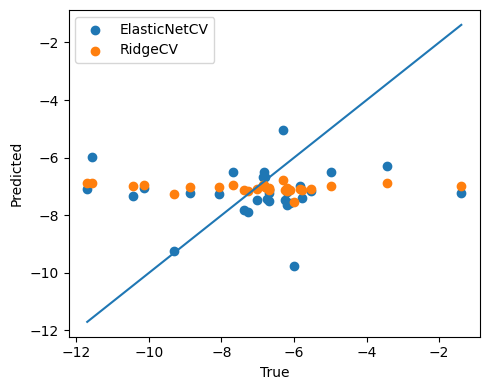

In [8]:
X = df[PRISTINE_FEATURES]
y = df[TARGET_COL].values

def build_elasticnetcv():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.05,0.1,0.2,0.3,0.5,0.7,0.9,0.95,0.99],  # include more ridge-like options
            cv=5, max_iter=200000, random_state=0
        ))
    ])

def build_ridgecv():
    # ridge is a good "grouping" baseline under correlation
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5))
    ])

pred_en = loocv_preds(X, y, build_elasticnetcv)
pred_ridge = loocv_preds(X, y, build_ridgecv)

report_metrics(y, pred_en, "ElasticNetCV (LOOCV)")
report_metrics(y, pred_ridge, "RidgeCV      (LOOCV)")

# Visual: predicted vs true
plt.figure(figsize=(5,4))
plt.scatter(y, pred_en, label="ElasticNetCV")
plt.scatter(y, pred_ridge, label="RidgeCV")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("True"); plt.ylabel("Predicted"); plt.legend(); plt.tight_layout()
plt.show()


## 4. Group-aware validation (chemical extrapolation)

Random CV can be overly optimistic if chemically similar points appear in both train and test.
Here we test extrapolation across periodic series by holding out entire groups (3d vs 4d vs 5d) using `LeaveOneGroupOut` / `GroupKFold` logic.

Interpretation:
- If a model performs well in random CV but collapses here, it was likely relying on periodic-trend shortcuts.
- If `eb` remains dominant **and** performance remains acceptable under group holdout, the dominance is more defensible.


## 8. Nonlinear but interpretable model: EBM

EBM is a generalized additive model trained by boosting shallow trees; it can capture smooth nonlinear effects while remaining interpretable.
Use the global explanation to inspect the learned shape functions (e.g., how `eb` or `gap` affects the prediction).


In [9]:
from sklearn.model_selection import LeaveOneGroupOut

def series_label(z):
    if 21 <= z <= 30:
        return "3d"
    if 39 <= z <= 48:
        return "4d"
    if 71 <= z <= 80:
        return "5d"
    return "other"

df["series"] = df["MTs"].apply(series_label)

logo = LeaveOneGroupOut()

def group_cv_preds(X, y, groups, model_builder):
    preds = np.zeros_like(y, dtype=float)
    for tr, te in logo.split(X, y, groups):
        m = model_builder()
        m.fit(X.iloc[tr], y[tr])
        preds[te] = m.predict(X.iloc[te])
    return preds

def report_by_group(y_true, y_pred, groups, label=""):
    print(label)
    for g in pd.unique(groups):
        m = (groups == g)
        r2, mae, rmse = report_metrics(y_true[m], y_pred[m], label=f"  test group={g}:")
    report_metrics(y_true, y_pred, label="  overall:")

groups = df["series"].values

pred_en_group   = group_cv_preds(df[PRISTINE_FEATURES], y, groups, build_elasticnetcv)
pred_ridge_group= group_cv_preds(df[PRISTINE_FEATURES], y, groups, build_ridgecv)
pred_ebm_group  = group_cv_preds(df[PRISTINE_FEATURES], y, groups, lambda: ExplainableBoostingRegressor(random_state=0))

report_by_group(y, pred_en_group, groups, "ElasticNetCV (group holdout)")
report_by_group(y, pred_ridge_group, groups, "RidgeCV      (group holdout)")
report_by_group(y, pred_ebm_group, groups, "EBM          (group holdout)")


ElasticNetCV (group holdout)
  test group=3d:  R2=-2.297  MAE=2.324  RMSE=2.843
  test group=4d:  R2=-0.019  MAE=1.718  RMSE=2.185
  test group=5d:  R2=-0.013  MAE=1.768  RMSE=2.481
  overall:  R2=-0.431  MAE=1.936  RMSE=2.517
RidgeCV      (group holdout)
  test group=3d:  R2=-0.731  MAE=1.760  RMSE=2.060
  test group=4d:  R2=0.016  MAE=1.695  RMSE=2.147
  test group=5d:  R2=0.032  MAE=1.730  RMSE=2.426
  overall:  R2=-0.109  MAE=1.728  RMSE=2.217
EBM          (group holdout)
  test group=3d:  R2=-0.691  MAE=1.765  RMSE=2.036
  test group=4d:  R2=0.037  MAE=1.826  RMSE=2.124
  test group=5d:  R2=0.108  MAE=1.695  RMSE=2.328
  overall:  R2=-0.059  MAE=1.762  RMSE=2.166


## 5. Feature importance via LOFO (drop-column) retraining

We avoid interpreting raw linear-model coefficients as “importance” because correlated descriptors can make coefficients unstable.
Instead, we use **LOFO / drop-column importance**: retrain the model without one feature and measure the degradation in CV error.
This approach is slower but more defensible when features are correlated.


In [10]:
def lofo_importance_loocv(X, y, build_model):
    """LOFO importance under outer LOOCV: retrain after dropping each feature."""
    # baseline
    base_pred = loocv_preds(X, y, build_model)
    base_r2 = r2_score(y, base_pred)
    base_mae = mean_absolute_error(y, base_pred)
    base_rmse = np.sqrt(mean_squared_error(y, base_pred))

    rows = []
    for col in X.columns:
        X_drop = X.drop(columns=[col])
        pred = loocv_preds(X_drop, y, build_model)
        r2 = r2_score(y, pred)
        mae = mean_absolute_error(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))

        rows.append({
            "dropped": col,
            "ΔR2 (drop)": r2 - base_r2,
            "ΔMAE (drop)": mae - base_mae,
            "ΔRMSE (drop)": rmse - base_rmse
        })

    out = pd.DataFrame(rows).sort_values("ΔMAE (drop)", ascending=False)
    return (base_r2, base_mae, base_rmse), out

# Ridge LOFO (fast baseline)
base_rd, lofo_rd = lofo_importance_loocv(df[PRISTINE_FEATURES], y, build_ridgecv)
print("Ridge baseline (R2, MAE, RMSE):", base_rd)
display(lofo_rd)

# ElasticNet LOFO is more expensive because it tunes hyperparameters internally.
RUN_ELASTICNET_LOFO = False
if RUN_ELASTICNET_LOFO:
    base_en, lofo_en = lofo_importance_loocv(df[PRISTINE_FEATURES], y, build_elasticnetcv)
    print("ElasticNet baseline (R2, MAE, RMSE):", base_en)
    display(lofo_en)


Ridge baseline (R2, MAE, RMSE): (-0.0264642219683342, 1.5037015187327012, np.float64(2.132343805453359))


,dropped,ΔR2 (drop),ΔMAE (drop),ΔRMSE (drop)
1,ecn,-0.009151,0.011522,0.009483
0,eb,-0.008189,0.008110,0.008489
7,gap,-0.008656,0.002442,0.008972
3,cgd,-0.003996,0.000758,0.004146
4,freq_min,-0.000256,0.000702,0.000266
2,dav,0.008494,-0.000257,-0.008841
6,e_0,0.012431,-0.002081,-0.012952
5,freq_max,0.021506,-0.006522,-0.022456


### 5b. LOFO under group holdout (3d vs 4d vs 5d)

This repeats LOFO, but evaluates drops under *group holdout* (more stringent, more aligned with chemical extrapolation).


In [11]:
def lofo_importance_groupholdout(X, y, groups, model_builder):
    base_pred = group_cv_preds(X, y, groups, model_builder)
    base_mae = mean_absolute_error(y, base_pred)
    base_rmse = np.sqrt(mean_squared_error(y, base_pred))

    rows = []
    for col in X.columns:
        pred = group_cv_preds(X.drop(columns=[col]), y, groups, model_builder)
        mae = mean_absolute_error(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rows.append({
            "dropped": col,
            "ΔMAE (drop)": mae - base_mae,
            "ΔRMSE (drop)": rmse - base_rmse
        })
    return pd.DataFrame(rows).sort_values("ΔMAE (drop)", ascending=False)

lofo_group_ridge = lofo_importance_groupholdout(df[PRISTINE_FEATURES], y, groups, build_ridgecv)
print("Group-holdout LOFO (RidgeCV):")
display(lofo_group_ridge)


Group-holdout LOFO (RidgeCV):


,dropped,ΔMAE (drop),ΔRMSE (drop)
0,eb,0.049279,0.032228
4,freq_min,0.034293,0.032003
7,gap,0.025444,0.023821
1,ecn,0.022194,0.020112
2,dav,0.001724,0.012217
6,e_0,-0.015610,-0.006899
3,cgd,-0.022057,-0.002170
5,freq_max,-0.076672,-0.041751


## 7. Residualization test: is the HOMO-LUMO gap adding signal beyond `eb`?

If `gap` is strongly correlated with `eb`, a linear model may attribute most weight to `eb` even when the gap contains additional information.
We remove the component of `gap` that is linearly explained by `eb` and re-evaluate with `gap_perp`.


In [12]:
# gap_perp: component of gap not linearly explained by eb
lin = LinearRegression().fit(df[["eb"]], df["gap"])
df["gap_perp"] = df["gap"] - lin.predict(df[["eb"]])

PRISTINE_FEATURES_PERP = ["eb","ecn","dav","cgd","freq_min","freq_max","e_0","gap_perp"]

X_perp = df[PRISTINE_FEATURES_PERP]

pred_ridge_perp = loocv_preds(X_perp, y, build_ridgecv)
report_metrics(y, pred_ridge_perp, "RidgeCV with gap_perp (LOOCV)")


RidgeCV with gap_perp (LOOCV)  R2=-0.043  MAE=1.512  RMSE=2.149


(-0.04253674245796857, 1.512499160908603, np.float64(2.1489732307466305))

In [13]:
def loocv_preds_model(X, y, model_builder):
    loo = LeaveOneOut()
    preds = np.zeros_like(y, dtype=float)
    for tr, te in loo.split(X):
        m = model_builder()
        m.fit(X.iloc[tr], y[tr])
        preds[te[0]] = m.predict(X.iloc[te])[0]
    return preds

pred_ebm = loocv_preds_model(df[PRISTINE_FEATURES], y, lambda: ExplainableBoostingRegressor(random_state=0))
report_metrics(y, pred_ebm, "EBM (LOOCV)")


EBM (LOOCV)  R2=0.036  MAE=1.660  RMSE=2.067


(0.03581755142788956, 1.6603585247605879, np.float64(2.0666404783139267))

## 6. Coefficient stability (ElasticNet)

Even when performance is acceptable, **coefficients can be unstable** under correlated predictors.
Here we fit ElasticNetCV repeatedly on bootstrap resamples and summarize how often each feature receives a non-zero weight.
This is a quick diagnostic for whether the “dominant” feature is genuinely stable.


,feature,selection_freq(|coef|>1e-6),coef_mean,coef_std
0,eb,0.790,0.280176,0.333888
7,gap,0.790,0.237506,0.520633
5,freq_max,0.765,-0.334795,0.505694
1,ecn,0.765,0.216820,0.277912
3,cgd,0.700,-0.131520,0.328363
2,dav,0.630,0.142781,0.313157
4,freq_min,0.600,0.028930,0.183408
6,e_0,0.540,0.181323,0.531953


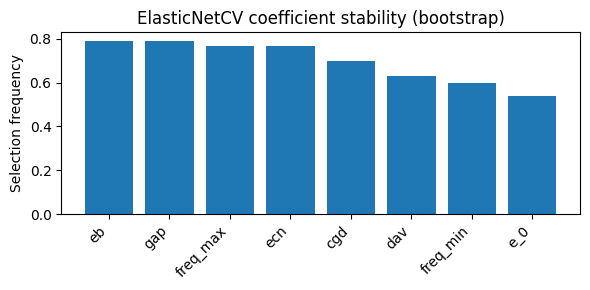

In [14]:
def bootstrap_elasticnet_coefs(n_boot=200, frac=0.8, seed=0):
    rng = np.random.default_rng(seed)
    coefs = []
    n = len(df)
    m = int(round(frac * n))
    for b in range(n_boot):
        idx = rng.choice(n, size=m, replace=True)
        model = build_elasticnetcv()
        model.fit(df.iloc[idx][PRISTINE_FEATURES], y[idx])
        coefs.append(model.named_steps["model"].coef_)
    coefs = np.vstack(coefs)
    return coefs

coefs = bootstrap_elasticnet_coefs(n_boot=200, frac=0.8, seed=0)

coef_summary = pd.DataFrame({
    "feature": PRISTINE_FEATURES,
    "selection_freq(|coef|>1e-6)": (np.abs(coefs) > 1e-6).mean(axis=0),
    "coef_mean": coefs.mean(axis=0),
    "coef_std": coefs.std(axis=0),
}).sort_values("selection_freq(|coef|>1e-6)", ascending=False)

display(coef_summary)

plt.figure(figsize=(6,3))
plt.bar(coef_summary["feature"], coef_summary["selection_freq(|coef|>1e-6)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Selection frequency")
plt.title("ElasticNetCV coefficient stability (bootstrap)")
plt.tight_layout()
plt.show()


In [15]:
# Example: enforce monotonic decreasing in eb (if physically justified), none elsewhere:
# -1 decreasing, 0 none, +1 increasing
mono = [ -1, 0, 0, 0, 0, 0, 0, 0 ]  # order matches PRISTINE_FEATURES

ebm_mono = ExplainableBoostingRegressor(random_state=0, monotone_constraints=mono)
ebm_mono.fit(df[PRISTINE_FEATURES], y)
show(ebm_mono.explain_global())


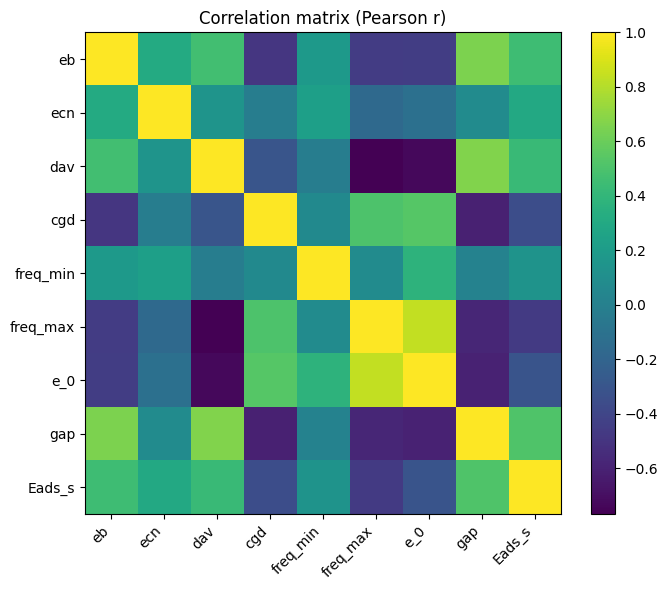

In [16]:
corr = df[PRISTINE_FEATURES + [TARGET_COL]].corr(numeric_only=True)

plt.figure(figsize=(7,6))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation matrix (Pearson r)")
plt.tight_layout()
plt.show()


## 9. Interpretation checklist

Use the results above to answer, objectively:

1) **Leakage?** Any near-perfect performance only appears when leaky variables (`e_int_s`, `e_dis_s`) are included.
2) **Generalization shift?** Compare random CV (LOOCV) vs **group holdout** (3d/4d/5d). Large drops indicate periodic-trend shortcuts.
3) **Is `eb` truly dominant?** Check:
   - LOFO deltas under group holdout;
   - ElasticNet coefficient stability (bootstrap selection frequency);
   - EBM shape functions (does `gap` have a non-flat effect?).


=== Baseline performance (group) ===
ElasticNetCV: R2=-0.431 | MAE=1.936 | RMSE=2.517
     RidgeCV: R2=-0.109 | MAE=1.728 | RMSE=2.217
         EBM: R2=-0.059 | MAE=1.762 | RMSE=2.166


/tmp/ipython-input-1716934991.py:243: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



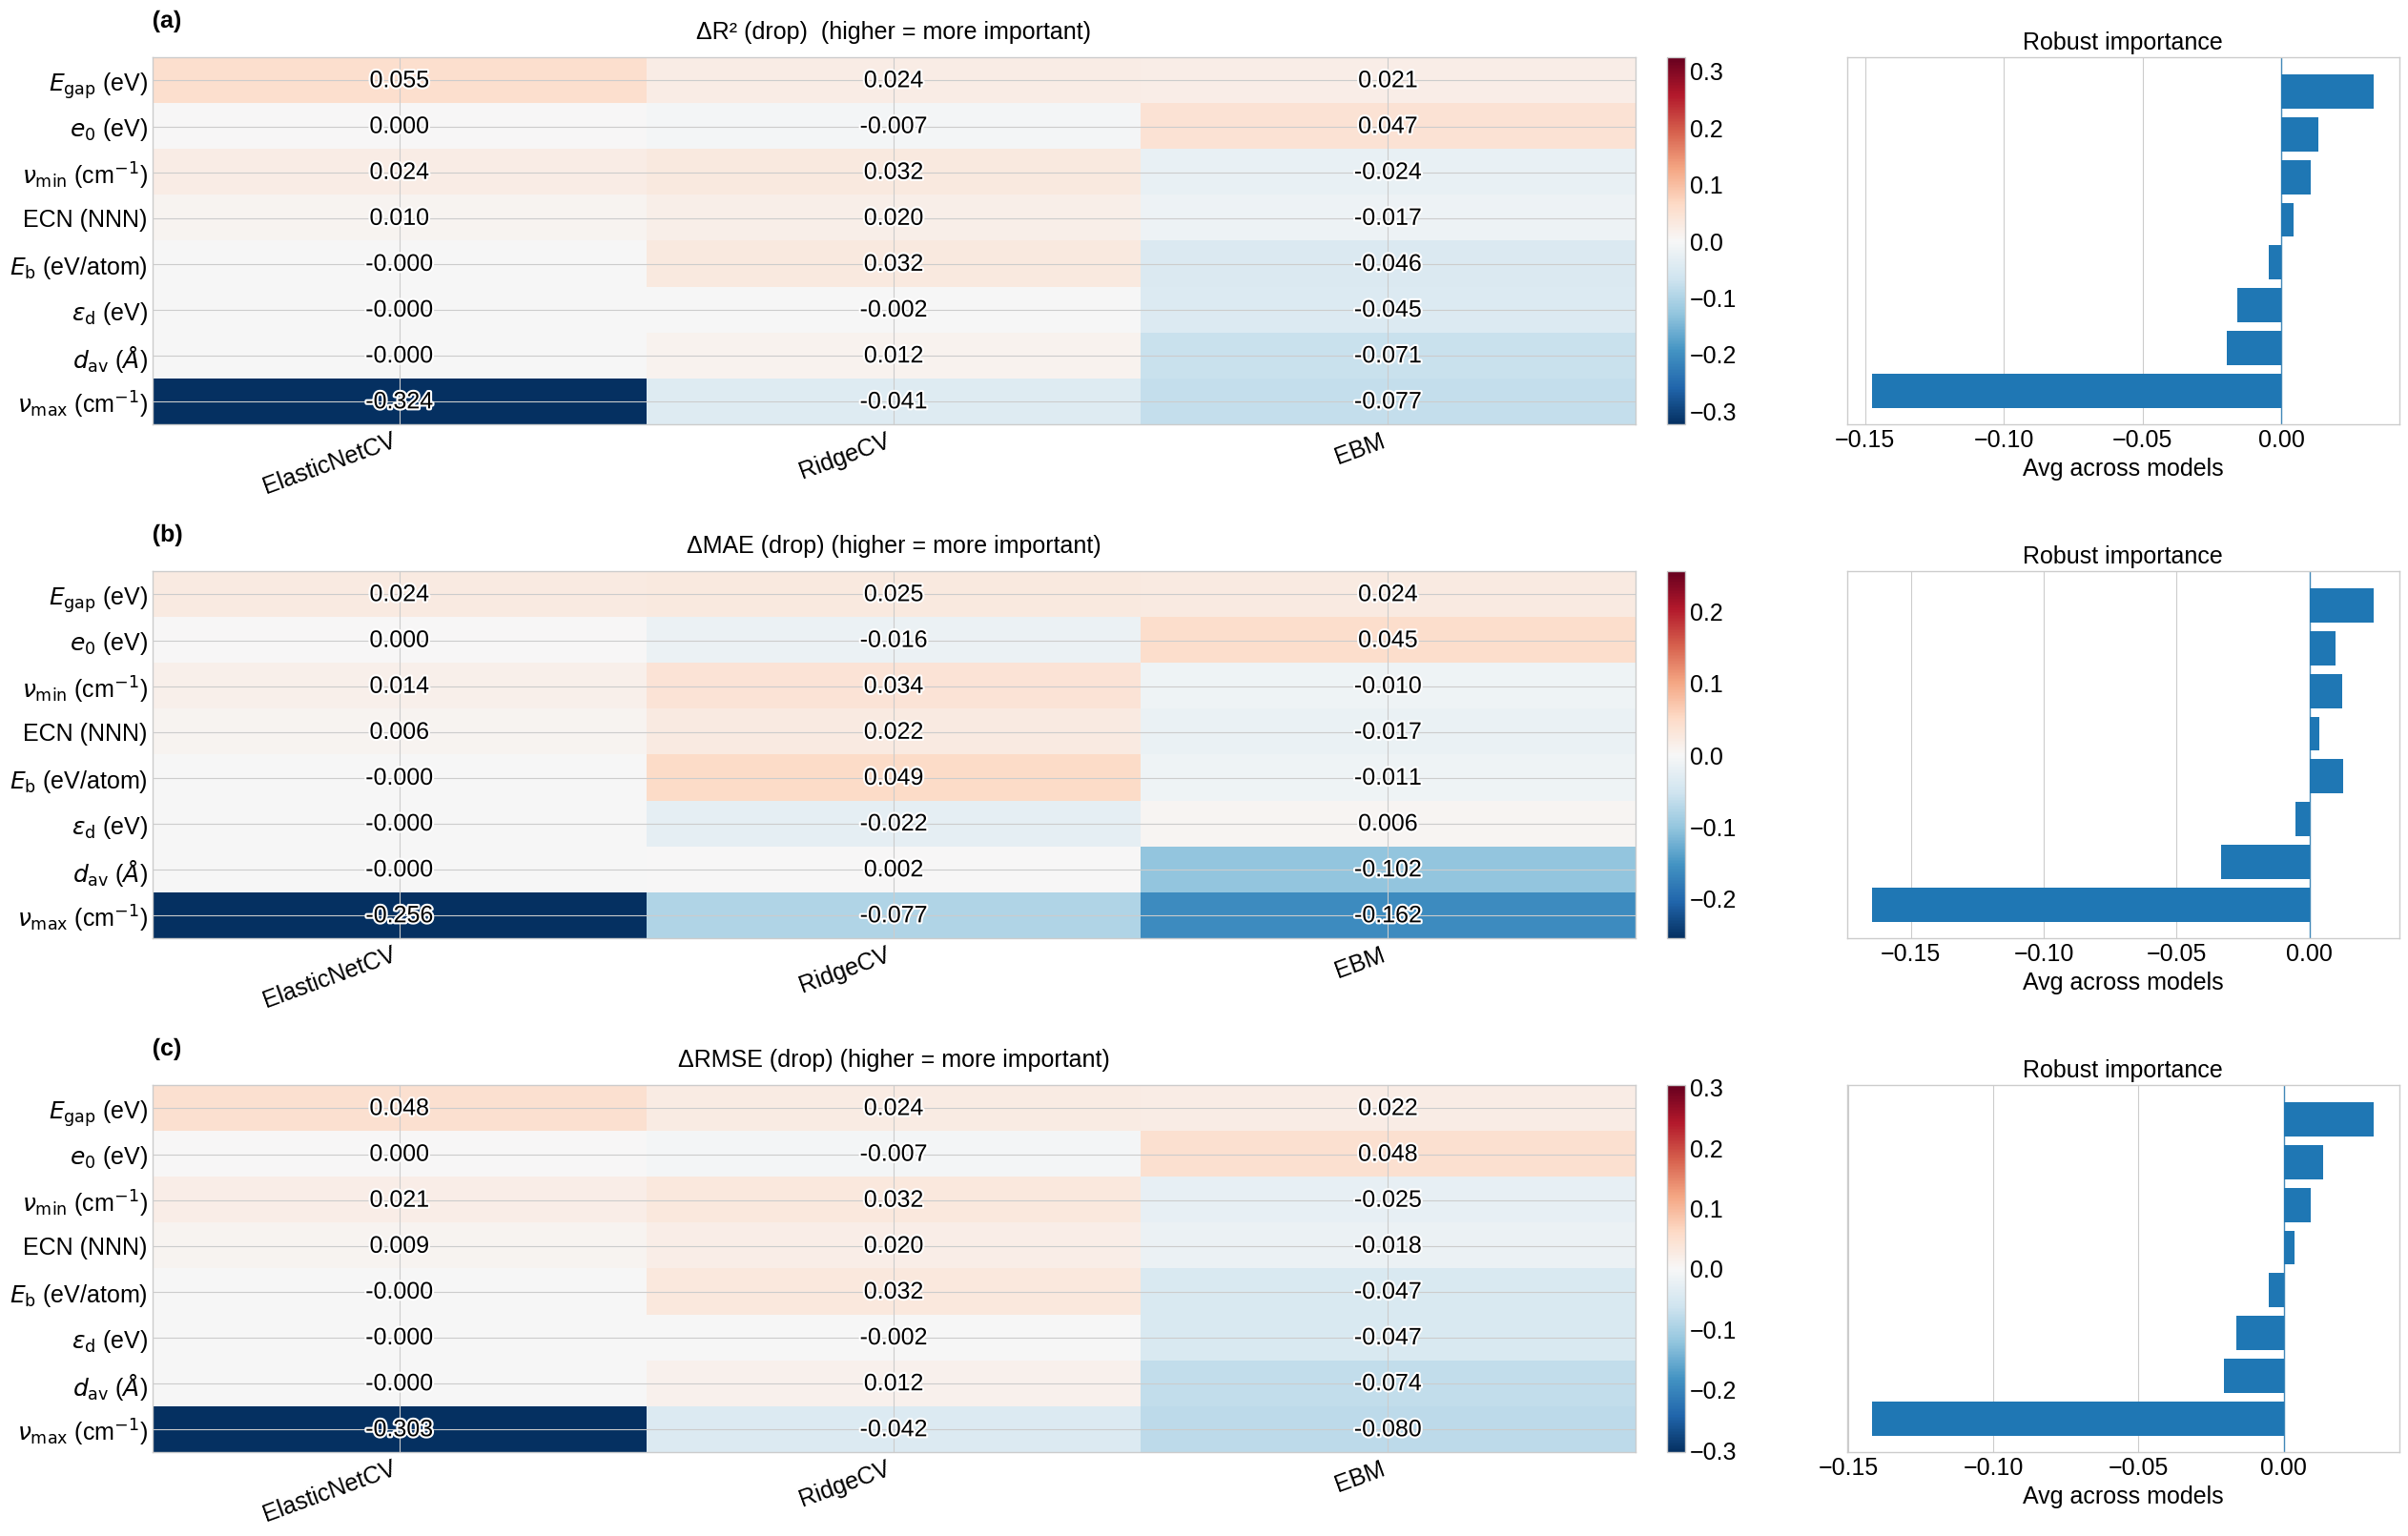

Saved: lofo_importance_groupcv.jpg


ΔR2_drop                        ΔMAE_drop                      \
         ElasticNetCV   RidgeCV       EBM ElasticNetCV   RidgeCV       EBM   
gap          0.055169  0.023968  0.021246     0.023715  0.025444  0.023900   
e_0          0.000000 -0.006894  0.047171     0.000000 -0.015610  0.045299   
freq_min     0.023821  0.032259 -0.023875     0.013690  0.034293 -0.010452   
ecn          0.009957  0.020219 -0.017190     0.006396  0.022194 -0.017124   
eb          -0.000025  0.032487 -0.045621    -0.000013  0.049279 -0.010795   
cgd         -0.000008 -0.002170 -0.045132    -0.000004 -0.022057  0.005976   
dav         -0.000026  0.012260 -0.071037    -0.000014  0.001724 -0.101665   
freq_max    -0.324160 -0.041390 -0.076946    -0.255594 -0.076672 -0.161681   

           ΔRMSE_drop                      
         ElasticNetCV   RidgeCV       EBM  
gap          0.048080  0.023821  0.021615  
e_0          0.000000 -0.006899  0.047705  
freq_min     0.020872  0.032003 -0.024551  
ecn          0.008745  0.020112 -0.017648  
eb          -0.000022  0.032228 -0.047158  
cgd         -0.000007 -0.002170 -0.046647  
dav         -0.000023  0.012217 -0.073892  
freq_max    -0.303499 -0.041751 -0.080156

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from interpret.glassbox import ExplainableBoostingRegressor

from joblib import Parallel, delayed

# ---- Settings ----
CV_SCHEME = "group"          # "group" (3d/4d/5d LeaveOneGroupOut) or "loocv"
TOPK = None                  # e.g., 8 to show only top-8 features; None = show all
RANDOM_STATE = 0

# Performance knobs (CPU parallelism)
LOFO_N_JOBS = -1             # parallelize over features inside LOFO
# Avoid oversubscription (especially when ElasticNetCV internally parallelizes)
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

# Heatmap styling
HEATMAP_CMAP = "RdBu_r"
SYMMETRIC_ABOUT_ZERO = True

# ---- Typography: ALL TEXT = 18 ----
FS = 18
TITLE_FONTSIZE = FS
PANEL_FONTSIZE = FS
LABEL_FONTSIZE = FS
TICK_FONTSIZE  = FS
CBAR_TICK_FONTSIZE = FS
ANNOT_FONTSIZE = FS

# Outline for readability while keeping BLACK font (black fill + white stroke)
WHITE_STROKE_LW = 3.0
outline_black_text = [pe.Stroke(linewidth=WHITE_STROKE_LW, foreground="white"), pe.Normal()]

# Panel labels
PANEL_LABELS = ["(a)", "(b)", "(c)"]

# ---- Feature label mapping (manuscript-consistent; NO '_' shown; UNITS included) ----
FEATURE_LABELS = {
    "eb":       r"$E_{\mathrm{b}}$ (eV/atom)",
    "ecn":      r"ECN (NNN)",
    "dav":      r"$d_{\mathrm{av}}$ ($\AA$)",
    "cgd":      r"$\varepsilon_{\mathrm{d}}$ (eV)",
    "freq_min": r"$\nu_{\min}$ (cm$^{-1}$)",
    "freq_max": r"$\nu_{\max}$ (cm$^{-1}$)",
    "e_0":      r"$e_{0}$ (eV)",
    "gap":      r"$E_{\mathrm{gap}}$ (eV)",
}
FALLBACK_UNIT = "a.u."

def pretty_feature_label(f: str) -> str:
    if f in FEATURE_LABELS:
        return FEATURE_LABELS[f]
    return f"{f.replace('_', ' ')} ({FALLBACK_UNIT})"

# ---- Assumes these exist: df, PRISTINE_FEATURES, y, groups, group_cv_preds/loocv_preds, build_elasticnetcv/build_ridgecv ----
X_full = df[PRISTINE_FEATURES].copy()
y_full = y.copy()

# ---- Model builders ----
# IMPORTANT: keep inner CV parallelism OFF (n_jobs=1) because we parallelize LOFO externally.
def _build_ebm():
    return ExplainableBoostingRegressor(random_state=RANDOM_STATE, n_jobs=-1)

def _build_elasticnet():
    # if your build_elasticnetcv already exists, we wrap it but ensure no oversubscription if possible
    m = build_elasticnetcv()
    # best-effort: if underlying estimator has n_jobs, set to 1
    try:
        if hasattr(m, "named_steps") and "model" in m.named_steps and hasattr(m.named_steps["model"], "n_jobs"):
            m.named_steps["model"].n_jobs = 1
    except Exception:
        pass
    return m

def _build_ridge():
    return build_ridgecv()

model_builders = {
    "ElasticNetCV": _build_elasticnet,
    "RidgeCV":      _build_ridge,
    "EBM":          _build_ebm,
}

def _cv_predict(X, y, model_builder, scheme="group"):
    if scheme == "group":
        return group_cv_preds(X, y, groups, model_builder)
    elif scheme == "loocv":
        return loocv_preds(X, y, model_builder)
    else:
        raise ValueError("scheme must be 'group' or 'loocv'")

def lofo_drops_all_metrics(X, y, model_builder, scheme="group", n_jobs=-1):
    # Baseline
    base_pred = _cv_predict(X, y, model_builder, scheme=scheme)
    base_r2   = r2_score(y, base_pred)
    base_mae  = mean_absolute_error(y, base_pred)
    base_rmse = np.sqrt(mean_squared_error(y, base_pred))

    def _one_feature(f):
        pred = _cv_predict(X.drop(columns=[f]), y, model_builder, scheme=scheme)
        r2   = r2_score(y, pred)
        mae  = mean_absolute_error(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        return {
            "feature": f,
            "ΔR2 (drop)":   base_r2 - r2,
            "ΔMAE (drop)":  mae - base_mae,
            "ΔRMSE (drop)": rmse - base_rmse,
        }

    rows = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(_one_feature)(f) for f in X.columns
    )

    out = pd.DataFrame(rows).set_index("feature")
    baseline = {"R2": base_r2, "MAE": base_mae, "RMSE": base_rmse}
    return baseline, out

# ---- Compute LOFO matrices for each model ----
baselines = {}
drops = {}

for name, builder in model_builders.items():
    base, df_drop = lofo_drops_all_metrics(X_full, y_full, builder, scheme=CV_SCHEME, n_jobs=LOFO_N_JOBS)
    baselines[name] = base
    drops[name] = df_drop

# ---- Assemble metric matrices: rows=features, cols=models ----
features = list(X_full.columns)

M_r2   = pd.DataFrame({m: drops[m]["ΔR2 (drop)"]   for m in model_builders.keys()}, index=features)
M_mae  = pd.DataFrame({m: drops[m]["ΔMAE (drop)"]  for m in model_builders.keys()}, index=features)
M_rmse = pd.DataFrame({m: drops[m]["ΔRMSE (drop)"] for m in model_builders.keys()}, index=features)

# Sort features by average ΔRMSE drop across models (robust ranking)
order = M_rmse.mean(axis=1).sort_values(ascending=False).index
M_r2, M_mae, M_rmse = M_r2.loc[order], M_mae.loc[order], M_rmse.loc[order]

if TOPK is not None:
    M_r2, M_mae, M_rmse = M_r2.head(TOPK), M_mae.head(TOPK), M_rmse.head(TOPK)

# ---- Print baselines ----
print(f"=== Baseline performance ({CV_SCHEME}) ===")
for m in model_builders.keys():
    b = baselines[m]
    print(f"{m:>12s}: R2={b['R2']:+.3f} | MAE={b['MAE']:.3f} | RMSE={b['RMSE']:.3f}")

# ---- Plot: 3 stacked heatmaps + average bars ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "font.size": FS,
})

metrics = [
    ("ΔR² (drop)  (higher = more important)", M_r2),
    ("ΔMAE (drop) (higher = more important)", M_mae),
    ("ΔRMSE (drop) (higher = more important)", M_rmse),
]

fig = plt.figure(figsize=(16 * 1.9, 10 * 1.9))
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[4.6, 1.6], hspace=0.40, wspace=0.10)

for i, (title, M) in enumerate(metrics):
    ax = fig.add_subplot(gs[i, 0])

    vmin = np.nanmin(M.values)
    vmax = np.nanmax(M.values)
    if SYMMETRIC_ABOUT_ZERO:
        max_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -max_abs, max_abs
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin - 1e-12, vmax + 1e-12

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    im = ax.imshow(
        M.values,
        aspect="auto",
        interpolation="nearest",
        cmap=HEATMAP_CMAP,
        norm=norm
    )

    title_obj = ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=14)
    ty = title_obj.get_position()[1] + 0.1
    ax.text(
        0.0, ty, PANEL_LABELS[i],
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=PANEL_FONTSIZE, fontweight="bold",
        color="black",
        path_effects=outline_black_text,
        clip_on=False,
        zorder=10
    )

    ax.set_xticks(np.arange(M.shape[1]))
    ax.set_xticklabels(M.columns, rotation=20, ha="right", fontsize=TICK_FONTSIZE)

    ylabels = [pretty_feature_label(f) for f in M.index]
    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_yticklabels(ylabels, fontsize=TICK_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    for (r, c), val in np.ndenumerate(M.values):
        if np.isnan(val):
            continue
        ax.text(
            c, r, f"{val:.3f}",
            ha="center", va="center",
            fontsize=ANNOT_FONTSIZE,
            color="black",
            path_effects=outline_black_text
        )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE, colors="black")

    axb = fig.add_subplot(gs[i, 1])
    avg = M.mean(axis=1)
    axb.barh(np.arange(len(avg)), avg.values)
    axb.axvline(0.0, linewidth=1.0, alpha=0.8)
    axb.set_yticks([])
    axb.invert_yaxis()
    axb.set_xlabel("Avg across models", fontsize=LABEL_FONTSIZE, color="black")
    axb.set_title("Robust importance", fontsize=LABEL_FONTSIZE, color="black")
    axb.tick_params(axis="x", labelsize=TICK_FONTSIZE, colors="black")

plt.tight_layout()

# --- save high-quality JPG (quality/subsampling) ---
out_path = f"lofo_importance_{CV_SCHEME}cv.jpg"
save_kwargs = dict(dpi=600, bbox_inches="tight", facecolor="white", format="jpg")
try:
    fig.savefig(out_path, pil_kwargs={"quality": 95, "subsampling": 0, "optimize": True}, **save_kwargs)
except TypeError:
    # older matplotlib: pil_kwargs not supported
    fig.savefig(out_path, **save_kwargs)

plt.show()
print("Saved:", out_path)

display(pd.concat(
    {"ΔR2_drop": M_r2, "ΔMAE_drop": M_mae, "ΔRMSE_drop": M_rmse},
    axis=1
))


## **Reproduce DFT adsorption-energy trends with 3 models (ElasticNetCV, RidgeCV, EBM)**

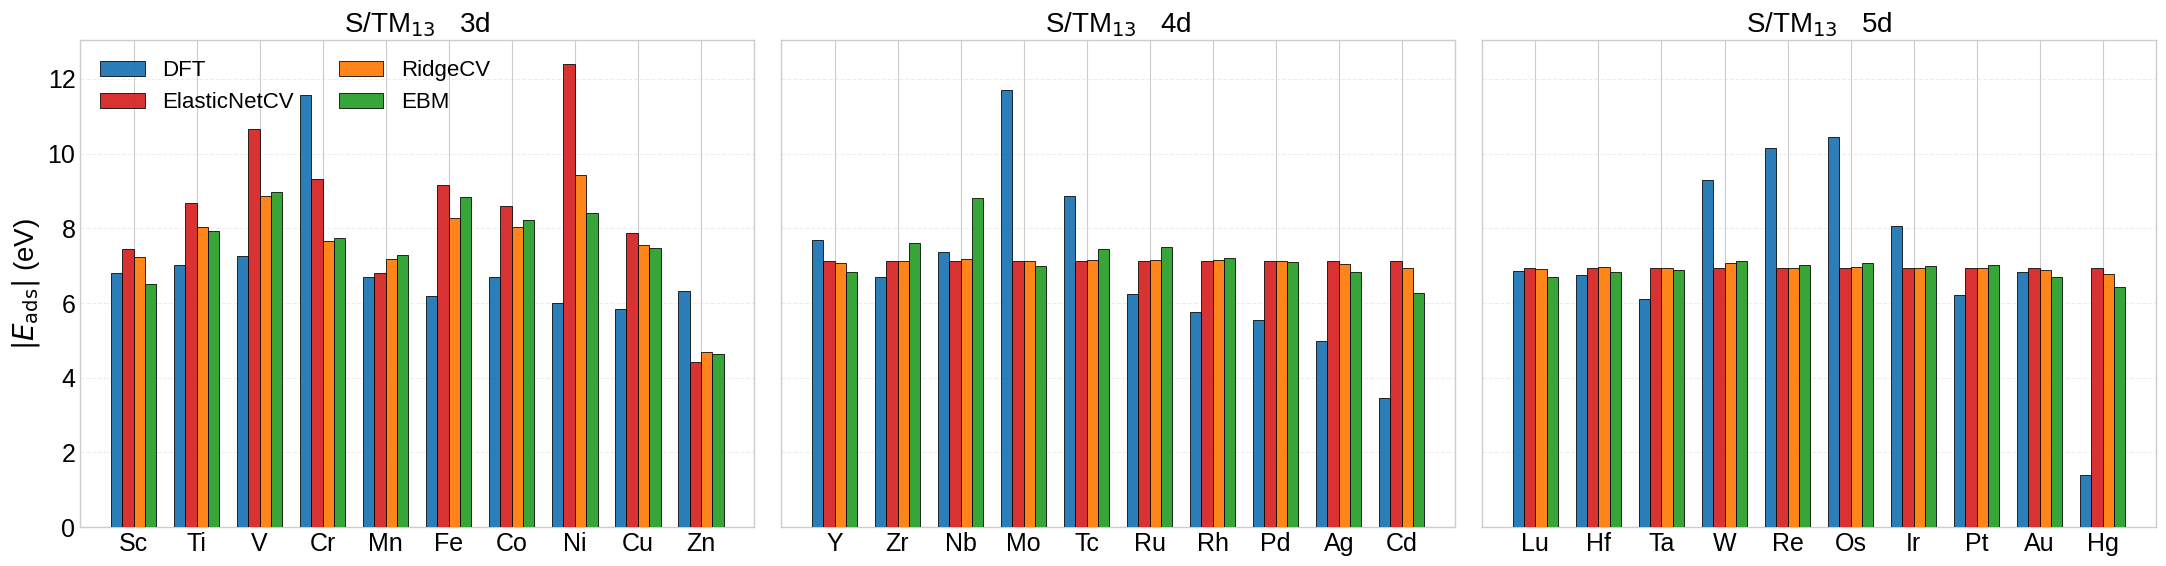

Saved: fig6_trends_3models_logo.jpg


In [18]:
# --- High-quality JPG trend figure (colors only) ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from interpret.glassbox import ExplainableBoostingRegressor

# Avoid oversubscription (Colab often benefits)
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

def _logo_preds(X, y, groups, model_builder):
    logo = LeaveOneGroupOut()
    preds = np.zeros(len(y), dtype=float)
    for tr, te in logo.split(X, y, groups):
        m = model_builder()
        m.fit(X.iloc[tr], y[tr])
        preds[te] = m.predict(X.iloc[te])
    return preds

def _default_build_elasticnetcv():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
            n_alphas=300,
            cv=5,
            random_state=0,
            max_iter=50000,
            n_jobs=-1,     # CPU parallel inside ElasticNetCV
        ))
    ])

def _default_build_ridgecv():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-8, 8, 300)))
    ])

build_elastic = build_elasticnetcv if "build_elasticnetcv" in globals() else _default_build_elasticnetcv
build_ridge   = build_ridgecv      if "build_ridgecv"      in globals() else _default_build_ridgecv
build_ebm     = (lambda: ExplainableBoostingRegressor(
    random_state=0,
    n_jobs=-1,
    max_bins=64,
    learning_rate=0.01,
    max_leaves=3,
    min_samples_leaf=2,
))

model_builders = {
    "ElasticNetCV": build_elastic,
    "RidgeCV":      build_ridge,
    "EBM":          build_ebm,
}

X = df[PRISTINE_FEATURES].copy()
y_arr = np.asarray(y, dtype=float)
groups_arr = np.asarray(groups)

use_abs = (np.nanmedian(y_arr) < 0)
y_plot = np.abs(y_arr) if use_abs else y_arr

preds = {}
for name, builder in model_builders.items():
    raw = _logo_preds(X, y_arr, groups_arr, builder)
    preds[name] = (np.abs(raw) if use_abs else raw)

def _infer_symbol_series(df):
    series_elems = {
        "3d": ["Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn"],
        "4d": ["Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd"],
        "5d": ["Lu","Hf","Ta","W","Re","Os","Ir","Pt","Au","Hg"],
    }
    all_elems = sum(series_elems.values(), [])
    for c in ["element", "elem", "symbol", "TM", "tm"]:
        if c in df.columns:
            sym = df[c].astype(str).str.strip()
            if sym.isin(all_elems).sum() >= 20:
                return sym.tolist(), series_elems
    for c in ["Z", "atomic_number", "MTs", "mt", "Z_TM"]:
        if c in df.columns:
            from pymatgen.core.periodic_table import Element
            sym = [Element.from_Z(int(z)).symbol for z in df[c].values]
            return sym, series_elems
    raise ValueError("Could not infer element symbols. Provide 'element' symbols or atomic numbers (e.g., 'MTs').")

symbols, series_elems = _infer_symbol_series(df)

res = pd.DataFrame({"Element": symbols, "DFT": y_plot, **preds})
ordered_all = series_elems["3d"] + series_elems["4d"] + series_elems["5d"]
res = res.set_index("Element").reindex(ordered_all).reset_index()

def _metrics(y_true, y_pred):
    return {
        "R2":   r2_score(y_true, y_pred),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

overall = {name: _metrics(res["DFT"].values, res[name].values) for name in model_builders}

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

colors = {
    "DFT":         "#1f77b4",
    "ElasticNetCV":"#d62728",
    "RidgeCV":     "#ff7f0e",
    "EBM":         "#2ca02c",
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
bar_w = 0.18
offsets = {"DFT": -1.5*bar_w, "ElasticNetCV": -0.5*bar_w, "RidgeCV": 0.5*bar_w, "EBM": 1.5*bar_w}

for ax, (series, elems) in zip(axes, series_elems.items()):
    sub = res.set_index("Element").loc[elems]
    x = np.arange(len(elems))
    for key in ["DFT", "ElasticNetCV", "RidgeCV", "EBM"]:
        ax.bar(
            x + offsets[key],
            sub[key].values,
            width=bar_w,
            color=colors[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.95,
            label=key if ax is axes[0] else None,
            zorder=3
        )
    ax.set_xticks(x)
    ax.set_xticklabels(elems)
    ax.set_title(rf"S/TM$_{{13}}$   {series}")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35, zorder=0)

axes[0].set_ylabel(r"$|E_{\mathrm{ads}}|$ (eV)" if use_abs else r"$E_{\mathrm{ads}}$ (eV)")
axes[0].legend(ncols=2, frameon=False, loc="upper left")

# lines = []
# for name in ["ElasticNetCV","RidgeCV","EBM"]:
#     m = overall[name]
#     lines.append(f"{name}: R²={m['R2']:+.2f}, MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}")
# axes[2].text(
#     1.02, 0.98, "\n".join(lines),
#     transform=axes[2].transAxes,
#     ha="left", va="top",
#     fontsize=14,
#     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.9)
# )

plt.tight_layout()

out_path = "fig6_trends_3models_logo.jpg"
save_kwargs = dict(dpi=600, bbox_inches="tight", facecolor="white", format="jpg")
try:
    fig.savefig(out_path, pil_kwargs={"quality": 95, "subsampling": 0, "optimize": True}, **save_kwargs)
except TypeError:
    fig.savefig(out_path, **save_kwargs)

plt.show()
print("Saved:", out_path)
